In [1]:
#TASK 1 -DATASET UNDERSTANDING

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("customer_support_text_classification.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [3]:
# Number of rows and columns

print("Rows and Columns:", df.shape)

Rows and Columns: (1500, 6)


In [4]:
# Target labels

print("Target Classes:")
print(df["sentiment_label"].unique())

Target Classes:
['neutral' 'positive' 'negative']


In [5]:
# Sample customer messages

print(df["customer_message"].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [6]:
# Average text length

df["text_length"] = df["customer_message"].apply(len)

print("Average Text Length:")
print(df["text_length"].mean())

Average Text Length:
72.75666666666666


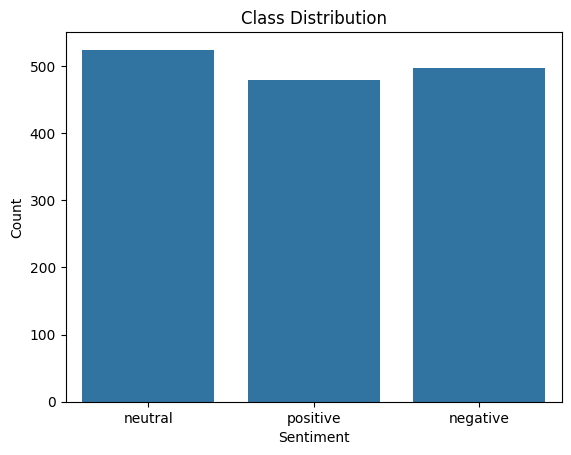

In [7]:
# Class distribution

sns.countplot(x=df["sentiment_label"])

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

#MARKDOWN
The dataset was explored to understand the number of records, target labels, and customer messages. Text length and class distribution were checked to better understand the dataset before building a model.

In [11]:
#TASK 2 -TEST PREPROCESSING

# Import NLP libraries

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
# Clean text

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df["clean_text"] = df["customer_message"].apply(clean_text)

df[["customer_message", "clean_text"]].head()

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


In [13]:
# Remove stopwords and tokenize

stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    words = word_tokenize(text)

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

df["processed_text"] = df["clean_text"].apply(preprocess_text)

df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,i need information about the payment process m...,need information payment process ticket number...
1,i need information about the payment process,need information payment process
2,the refund process was fast and convenient i a...,refund process fast convenient appreciate quic...
3,my refund is still pending and this experience...,refund still pending experience frustrating ti...
4,please tell me how to update my account details,please tell update account details


#MARKDOWN
The text data was cleaned by converting it to lowercase and removing unnecessary symbols. Tokenization and stopword removal were applied to make the text more useful for modeling.

In [14]:
#TASK 3 -TEST VECTORIZATION

# TF-IDF vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["processed_text"])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (1500, 146)


In [15]:
# Encode target labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["sentiment_label"])

print(encoder.classes_)

['negative' 'neutral' 'positive']


In [16]:
# Convert text into sequences

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["processed_text"])

sequences = tokenizer.texts_to_sequences(df["processed_text"])

X_seq = pad_sequences(sequences, maxlen=50)

print("Sequence Shape:", X_seq.shape)

Sequence Shape: (1500, 50)


#MARKDOWN
Text cannot be used directly by machine learning models because models work with numbers. TF-IDF and tokenizer-based sequences convert text into numerical form so patterns can be learned.

In [18]:
#TASK 4 -BASELINE MODEL

# Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


In [19]:
# Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [20]:
# Predictions

y_pred = model.predict(X_test)

In [21]:
# Model evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



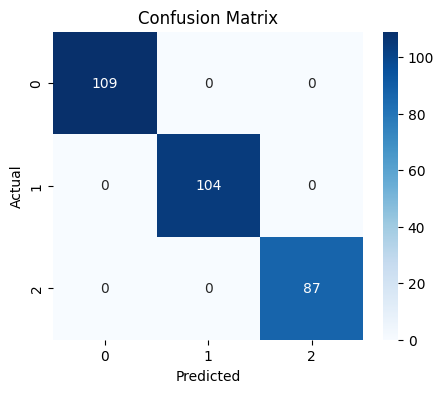

In [22]:
# Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("model_evaluation.png")

plt.show()

In [23]:
# Save sample predictions

sample_df = pd.DataFrame({
    "Text": df["customer_message"].head(10),
    "Actual": encoder.inverse_transform(y[:10]),
    "Predicted": encoder.inverse_transform(
        model.predict(X_tfidf[:10])
    )
})

with open("sample_predictions.txt", "w") as f:
    f.write(sample_df.to_string())

sample_df

,Text,Actual,Predicted
0,I need information about the payment process. ...,neutral,neutral
1,I need information about the payment process.,neutral,neutral
2,The refund process was fast and convenient. I ...,positive,positive
3,My refund is still pending and this experience...,negative,negative
4,Please tell me how to update my account details.,neutral,neutral
5,I need help finding the invoice for my last or...,neutral,neutral
6,I am satisfied with the plan and would recomme...,positive,positive
7,I want to understand the warranty terms for th...,neutral,neutral
8,I need help finding the invoice for my last or...,neutral,neutral
9,My refund is still pending and this experience...,negative,negative


#MARKDOWN
A Logistic Regression model was trained using TF-IDF features. The model performance was checked using accuracy, classification report, and confusion matrix.

In [24]:
#TASK 5 -SEQUENCE MODEL (LSTM)

# Sequence train test split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000, output_dim=64)
)

lstm_model.add(
    LSTM(64)
)

lstm_model.add(
    Dense(3, activation='softmax')
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train model

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.5635 - loss: 1.0022 - val_accuracy: 0.8542 - val_loss: 0.7766
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7031 - loss: 0.7458 - val_accuracy: 0.8583 - val_loss: 0.5927
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9458 - loss: 0.3783 - val_accuracy: 1.0000 - val_loss: 0.2105
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.0000 - loss: 0.1158 - val_accuracy: 1.0000 - val_loss: 0.0532
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 0.0200


#MARKDOWN
The LSTM model processes text as sequences. It first converts words into embeddings, then learns patterns using sequence memory before predicting the final sentiment class.

#Task 6: Attention and Transformer Reflection
1. Why RNNs struggle with long-term dependencies
RNNs process text one word at a time and try to remember previous information.
When the sentence becomes very long, the model may forget important information from earlier words.
This problem is called the long-term dependency problem.
Because of this, RNNs sometimes do not perform well on long and complex sentences.
2. How LSTMs help with memory
LSTM is an improved version of RNN that is better at remembering information.
It uses special gates to decide what information should be remembered and what should be forgotten.
This helps the model keep important information for a longer time.
Due to this feature, LSTMs generally work better than simple RNNs for text-related tasks.
3. What attention solves in sequence-to-sequence tasks
Attention helps the model focus on the most important words instead of treating all words equally.
It allows the model to look back at relevant parts of the sentence while making predictions.
This improves performance in tasks like translation, text generation, and summarization.
Attention helps the model understand context in a better way.
4. Why transformers are important in modern NLP and Generative AI
Transformers are faster and more powerful than older sequence models like RNNs and LSTMs.
They can process many words at the same time instead of one by one.
Transformers understand context better and work well on very large datasets.
Modern AI tools and language models use transformers because they are highly efficient for understanding and generating text.